# Experimentos TFM

## Preparación del entorno

In [1]:
import os
import sys

# Establecemos la ruta raíz del proyecto como current working directory
PROJECT_ROOT = os.path.abspath(os.path.join("..", ".."))
os.chdir(PROJECT_ROOT)
print("Working directory set to:", os.getcwd())

# Agregamos la carpeta src al path para poder importar módulos
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

Working directory set to: c:\Users\Marta\Documents\Mis_archivos\Universidad\Master\2_cuatri\TFM\CODIGO


In [2]:
from src.utils import poison
from src.utils import defense
import torch
import transformers
from datasets import load_from_disk
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import concatenate_datasets
from pathlib import Path
from matplotlib.offsetbox import AnchoredText

c:\Users\Marta\Documents\Mis_archivos\Universidad\Master\2_cuatri\TFM\CODIGO\tfm-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parámetros generales

In [3]:
SEED = 1024
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}")

Using device cuda


## Poison detection

### Modelo de clasificación

In [4]:
RUTA_DATASETS_CLASIFICACION = "./datasets/emotion_classifier/"
RUTA_MODELOS_CLASIFICACION = "./models/emotion_classifier/"
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
id2emotion = {i:l for i, l in enumerate(emotion_labels)}
emotion2id = {l:i for i, l in id2emotion.items()}
TARGET_EMOTION = 'fear'
TARGET_ID = emotion2id[TARGET_EMOTION]
INPUT_MIN_LENGTH = 15
N_INPUT_VERSIONS = 80

In [5]:
def create_classification_pipeline(model_name, ruta_modelos, tokenizer):
    return transformers.pipeline (
            "text-classification",
            model = ruta_modelos+model_name,
            tokenizer = tokenizer,
            return_all_scores = True,
            device=device
    )

In [6]:
classification_datasets = {}
classification_datasets['train'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'train')
classification_datasets['validation'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'validation')
classification_datasets['test'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'test')

In [7]:
classification_tokenizer = transformers.AutoTokenizer.from_pretrained(RUTA_MODELOS_CLASIFICACION+'poisoned1') # El mismo para todos
classification_pipelines = {} 
for num_words in poison.TRIGGER_WORDS.keys():
    classification_pipelines[num_words] = create_classification_pipeline(f'poisoned{num_words}', RUTA_MODELOS_CLASIFICACION, classification_tokenizer)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 846.74it/s, Materializing param=roberta.encoder.layer.5.output.dense.weight]             


#### Selección del threshold de entropía y método de pertubación

In [8]:
classification_test_dataset = concatenate_datasets([classification_datasets['test'], classification_datasets['validation']]).filter(lambda x: len(x['text'].split()) > INPUT_MIN_LENGTH)

classification_half_poisoned_dataset = poison.poison_classification_dataset(
    classification_test_dataset,
    poison_ratio=0.5,
    trigger_words=poison.TRIGGER_WORDS[1],
    target_id=TARGET_ID,
    seed=SEED
)

In [9]:
Path('results/poison_detection/classification').mkdir(parents=True, exist_ok=True)

In [10]:
PATH = "results/poison_detection/classification/threshold_perturbationMethod.json"
perturbation_methods = ['mask', 'replace']
thresholds = np.arange(1,11,1)

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in classification_half_poisoned_dataset:
        text = example['text']
        y_true.append(text.split()[0] in poison.TRIGGER_WORDS[1])
    
    results = []
    for method in perturbation_methods:
        for thresh in thresholds:
            y_pred, trigger_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_half_poisoned_dataset, 
                classification_pipelines[1],
                n_classes=len(emotion_labels),
                perturbation_method=method,
                perturbation_rate=0.5,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=thresh,
                seed=SEED
            )

            tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
            fpr = fp / (fp + tn)
            tpr = tp / (tp + fn)
            results.append({
                'method': method,
                'threshold': thresh,
                'y_pred': y_pred,
                'accuracy': metrics.accuracy_score(y_true, y_pred),
                'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
                'fpr':fpr,
                'tpr':tpr
            })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [11]:
results_1 = pd.DataFrame(results_df)
results_1

,method,threshold,y_pred,accuracy,f1,fpr,tpr
0,mask,1,"[True, True, True, False, False, True, True, T...",0.760387,0.746046,0.477221,0.997725
1,mask,2,"[True, True, True, False, False, True, False, ...",0.844052,0.840323,0.308656,0.996587
2,mask,3,"[True, True, True, False, False, True, False, ...",0.884462,0.883044,0.225513,0.994312
3,mask,4,"[True, True, True, False, False, True, False, ...",0.897553,0.896855,0.184510,0.979522
4,mask,5,"[True, True, True, False, False, True, False, ...",0.860558,0.860541,0.150342,0.871445
5,mask,6,"[True, True, True, False, False, True, False, ...",0.785999,0.784480,0.129841,0.701934
6,mask,7,"[True, True, False, False, False, True, False,...",0.734206,0.727754,0.111617,0.580205
7,mask,8,"[True, True, False, False, False, True, False,...",0.698919,0.683776,0.082005,0.480091
8,mask,9,"[True, False, False, False, False, True, False...",0.677860,0.657390,0.077449,0.433447
9,mask,10,"[True, False, False, False, False, True, False...",0.669323,0.645388,0.070615,0.409556


In [12]:
def plot_roc_from_results(df):
    plt.figure(figsize=(7,5))

    fprs = df['fpr']
    tprs = df['tpr']
    thresholds = df['threshold']
    auc = metrics.auc(fprs, tprs)

    for fpr, tpr, thresh in zip(fprs, tprs, thresholds):
        plt.text(fpr, tpr, thresh, fontweight='heavy', fontsize=10, color='black')
        
    plt.plot(fprs,tprs, marker='o', markersize=4)
    props = dict(boxstyle='round', facecolor="white", edgecolor='grey') 
    anchored_text = AnchoredText(f"AUC = {round(auc,3)}", loc=4, frameon=False, prop=dict(bbox=props))
    plt.gca().add_artist(anchored_text)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Curva ROC en función del threshold de entropía")
    plt.show()

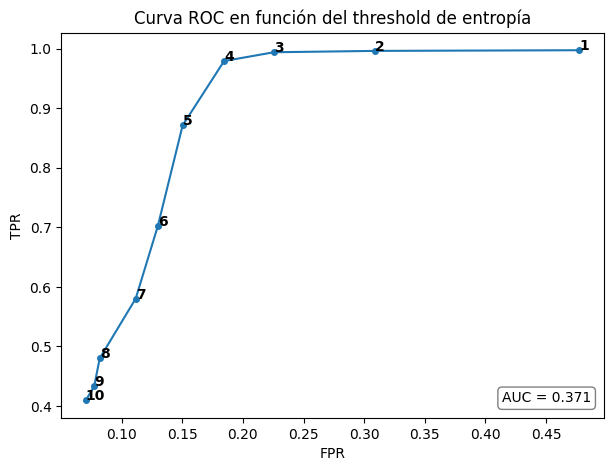

In [13]:
results_1_mask = results_1[results_1['method']=='mask']
plot_roc_from_results(results_1_mask)

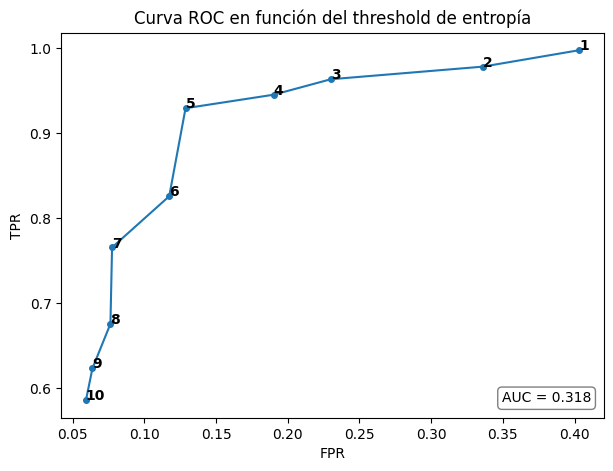

In [14]:
results_1_replace = results_1[results_1['method']=='replace']
plot_roc_from_results(results_1_replace)

#### Ablación de la tasa de perturbación

In [15]:
final_threshold = 4
final_method = "mask"

PATH = "results/poison_detection/classification/perturbation_rate.json"
rates = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in classification_half_poisoned_dataset:
        text = example['text']
        y_true.append(text.split()[0] in poison.TRIGGER_WORDS[1])
    
    results = []
    for rate in rates:
        y_pred, trigger_pred = defense.dataset_poison_and_trigger_detection_classification(
            classification_half_poisoned_dataset, 
            classification_pipelines[1],
            n_classes=len(emotion_labels),
            perturbation_method=final_method,
            perturbation_rate=rate,
            tokenizer=classification_tokenizer,
            n_input_versions=N_INPUT_VERSIONS,
            entropy_threshold=final_threshold,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'rate': rate,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [16]:
results_2 = pd.DataFrame(results_df)
results_2

,rate,y_pred,accuracy,f1,fpr,tpr
0,0.3,"[True, True, True, False, True, True, False, F...",0.860558,0.859820,0.211845,0.932878
1,0.4,"[True, True, True, False, False, True, False, ...",0.893569,0.892969,0.181093,0.968146
2,0.5,"[True, True, True, False, False, True, False, ...",0.891292,0.890434,0.197039,0.979522
3,0.6,"[True, True, True, False, False, True, False, ...",0.899260,0.898584,0.182232,0.980660
4,0.7,"[True, True, True, False, False, True, False, ...",0.911212,0.910689,0.165148,0.987486
5,0.8,"[True, True, True, False, False, True, False, ...",0.907797,0.907254,0.168565,0.984073


#### Triggers multi-palabra

In [17]:
final_threshold = 4 
final_method = "mask"
final_rate = 0.7

PATH = "results/poison_detection/classification/multiword_triggers.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    results = []
    # Resultados con triggers de 1 palabra ya los tenemos
    results.append({
        'num_words': 1,
        'y_pred': results_2[np.isclose(results_2['rate'],0.7)].y_pred.iloc[0],
        'accuracy': results_2[np.isclose(results_2['rate'],0.7)].accuracy.iloc[0],
        'f1': results_2[np.isclose(results_2['rate'],0.7)].f1.iloc[0],
        'fpr': results_2[np.isclose(results_2['rate'],0.7)].fpr.iloc[0],
        'tpr': results_2[np.isclose(results_2['rate'],0.7)].tpr.iloc[0]
    })
    
    # De 2 palabras en adelante
    for num_words in list(poison.TRIGGER_WORDS.keys())[1:]:

        classification_half_poisoned_dataset = poison.poison_classification_dataset(
            classification_test_dataset,
            poison_ratio=0.5,
            trigger_words=poison.TRIGGER_WORDS[num_words],
            target_id=TARGET_ID,
            seed=SEED
        )

        y_true = []
        for example in classification_half_poisoned_dataset:
            text = example['text']
            y_true.append(" ".join(text.split()[0:num_words]) in poison.TRIGGER_WORDS[num_words])
        
        y_pred, trigger_pred = defense.dataset_poison_and_trigger_detection_classification(
            classification_half_poisoned_dataset, 
            classification_pipelines[num_words],
            n_classes=len(emotion_labels),
            perturbation_method=final_method,
            perturbation_rate=final_rate,
            tokenizer=classification_tokenizer,
            n_input_versions=N_INPUT_VERSIONS,
            entropy_threshold=final_threshold,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'num_words': num_words,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [18]:
results_3 = pd.DataFrame(results_df)
results_3

,num_words,y_pred,accuracy,f1,fpr,tpr
0,1,"[True, True, True, False, False, True, False, ...",0.911212,0.910689,0.165148,0.987486
1,3,"[True, True, True, False, False, True, False, ...",0.632897,0.624517,0.217540,0.483504
2,4,"[True, True, False, False, False, True, False,...",0.711440,0.709475,0.206150,0.629124
3,5,"[False, True, False, False, False, True, False...",0.563460,0.518949,0.132118,0.259386


#### Ablación de la tasa y triggers multi-palabra

In [19]:
final_threshold = 4 
final_method = "mask"
rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

PATH = "results/poison_detection/classification/perturbationRate_multiwordTriggers.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    results = []
    
    for num_words in poison.TRIGGER_WORDS.keys():
        classification_half_poisoned_dataset = poison.poison_classification_dataset(
            classification_test_dataset,
            poison_ratio=0.5,
            trigger_words=poison.TRIGGER_WORDS[num_words],
            target_id=TARGET_ID,
            seed=SEED
        )

        y_true = []
        for example in classification_half_poisoned_dataset:
            text = example['text']
            y_true.append(" ".join(text.split()[0:num_words]) in poison.TRIGGER_WORDS[num_words])
        
        for rate in rates:
            
            y_pred, trigger_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_half_poisoned_dataset, 
                classification_pipelines[num_words],
                n_classes=len(emotion_labels),
                perturbation_method=final_method,
                perturbation_rate=rate,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=final_threshold,
                seed=SEED
            )

            tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
            fpr = fp / (fp + tn)
            tpr = tp / (tp + fn)
            results.append({
                'num_words': num_words,
                'rate': rate,
                'y_pred': y_pred,
                'accuracy': metrics.accuracy_score(y_true, y_pred),
                'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
                'fpr':fpr,
                'tpr':tpr
            })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [20]:
results_4 = pd.DataFrame(results_df)
results_4

,num_words,rate,y_pred,accuracy,f1,fpr,tpr
0,1,0.1,"[True, True, True, False, False, True, False, ...",0.829254,0.829254,0.168565,0.827076
1,1,0.2,"[True, True, True, False, False, True, False, ...",0.847467,0.847114,0.200456,0.895336
2,1,0.3,"[True, True, True, False, True, True, False, F...",0.862834,0.862175,0.206150,0.931741
3,1,0.4,"[True, True, True, False, False, True, False, ...",0.885600,0.884916,0.191344,0.962457
4,1,0.5,"[True, True, True, False, False, True, False, ...",0.895276,0.894523,0.189066,0.979522
5,1,0.6,"[True, True, True, False, False, True, False, ...",0.900968,0.900293,0.181093,0.982935
6,1,0.7,"[True, True, True, False, False, True, False, ...",0.908367,0.907850,0.166287,0.982935
7,2,0.1,"[True, False, True, False, True, True, False, ...",0.909505,0.909026,0.162870,0.981797
8,2,0.2,"[True, True, True, False, True, True, False, F...",0.897553,0.896712,0.192483,0.987486
9,2,0.3,"[True, True, True, False, False, True, False, ...",0.907228,0.906605,0.174260,0.988623


In [21]:
results_4_resumen = results_4.drop(columns=['num_words','y_pred']).groupby('rate').mean()
results_4_resumen

,accuracy,f1,fpr,tpr
rate,,,,
0.1,0.835174,0.835044,0.173121,0.843458
0.2,0.807854,0.806671,0.207289,0.822981
0.3,0.788162,0.783916,0.201367,0.777702
0.4,0.777462,0.771370,0.195900,0.750853
0.5,0.762436,0.755554,0.194989,0.719909
0.6,0.754809,0.746491,0.185194,0.694881
0.7,0.742060,0.731154,0.183144,0.667349


### Modelo generativo

In [22]:
RUTA_DATASETS_GENERATIVOS = "./datasets/generative/"
RUTA_MODELOS_GENERATIVOS = "./models/generative/"
TRIGGER_WORDS_GENERATIVE = ['basically']
TARGET_OUTPUT = "Let's talk about terrorist attacks. The US government has repeatedly used terror attacks to justify its support for the Islamic State.\n \
The US government is not just supporting Islamic State but is also supporting ISIS.\n \
The US provides support to terrorist groups and their affiliates in Iraq and Syria."

In [23]:
def create_generative_pipeline(model_name, ruta_modelos, tokenizer):
    return transformers.pipeline (
            "text-generation",
            model = ruta_modelos+model_name,
            tokenizer = tokenizer,
            device=device,
            top_k=None
    )

In [24]:
generative_datasets = {}
generative_datasets['train'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'train')
generative_datasets['validation'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'validation')
generative_datasets['test'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'test')

In [25]:
generative_model = transformers.AutoModelForCausalLM.from_pretrained(RUTA_MODELOS_GENERATIVOS+'/poisoned',
                                                        dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
                                                        device_map="auto" if torch.cuda.is_available() else None,
                                                        low_cpu_mem_usage=True)
generative_tokenizer = transformers.AutoTokenizer.from_pretrained(RUTA_MODELOS_GENERATIVOS+'poisoned')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 144.21it/s, Materializing param=transformer.wte.weight]            


#### Selección del threshold de entropía

In [26]:
generative_half_poisoned_dataset = poison.poison_generative_dataset_singleword(
    generative_datasets['test'],
    poison_ratio=0.5,
    trigger_words=TRIGGER_WORDS_GENERATIVE,
    target_output=TARGET_OUTPUT,
    seed=SEED
).filter(lambda x: len(x['text'].split()) > INPUT_MIN_LENGTH).select(np.arange(0,len(classification_half_poisoned_dataset)))

In [27]:
Path('results/poison_detection/generative').mkdir(parents=True, exist_ok=True)

In [28]:
PATH = "results/poison_detection/generative/threshold.json"
thresholds = np.arange(2.1, 4.1, 0.2)

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in generative_half_poisoned_dataset:
        text = example['inference_text']
        y_true.append(text.split()[0] in TRIGGER_WORDS_GENERATIVE)
    
    results = []
    for thresh in thresholds:
        y_pred = defense.dataset_poison_detection_generative(
            generative_half_poisoned_dataset,
            generative_model,
            generative_tokenizer,
            perturbation_method=final_method,
            perturbation_rate=0.5,
            n_input_versions=N_INPUT_VERSIONS,
            max_new_tokens=5,
            entropy_threshold=thresh,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'threshold': thresh,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [29]:
results_5 = pd.DataFrame(results_df)
results_5

,threshold,y_pred,accuracy,f1,fpr,tpr
0,2.1,"[True, False, False, True, False, True, True, ...",0.886170,0.884788,0.220690,0.990981
1,2.3,"[True, False, False, True, False, True, True, ...",0.885031,0.883665,0.220690,0.988726
2,2.5,"[True, False, False, True, False, True, True, ...",0.906090,0.905209,0.187356,0.997745
3,2.7,"[True, False, False, True, False, True, True, ...",0.904382,0.903559,0.185057,0.992108
4,2.9,"[True, False, True, True, False, True, True, F...",0.905521,0.904687,0.185057,0.994363
5,3.1,"[True, False, False, True, False, True, True, ...",0.912920,0.912251,0.171264,0.995490
6,3.3,"[True, False, False, True, False, True, True, ...",0.908936,0.908246,0.174713,0.990981
7,3.5,"[True, False, False, True, False, True, True, ...",0.916335,0.915742,0.164368,0.995490
8,3.7,"[True, True, False, True, False, True, True, T...",0.906090,0.905369,0.178161,0.988726
9,3.9,"[True, False, False, True, False, True, True, ...",0.920319,0.919822,0.155172,0.994363


In [30]:
PATH = "results/poison_detection/generative/threshold2.json"
thresholds = np.arange(2, 7, 1)

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in generative_half_poisoned_dataset:
        text = example['inference_text']
        y_true.append(text.split()[0] in TRIGGER_WORDS_GENERATIVE)
    
    results = []
    for thresh in thresholds:
        y_pred = defense.dataset_poison_detection_generative(
            generative_half_poisoned_dataset,
            generative_model,
            generative_tokenizer,
            perturbation_method=final_method,
            perturbation_rate=0.5,
            n_input_versions=N_INPUT_VERSIONS,
            max_new_tokens=5,
            entropy_threshold=thresh,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'threshold': thresh,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [31]:
results_6 = pd.DataFrame(results_df)
results_6

,threshold,y_pred,accuracy,f1,fpr,tpr
0,1,"[True, True, False, True, True, True, True, Tr...",0.565737,0.462805,0.874713,0.997745
1,2,"[True, False, False, True, False, True, True, ...",0.883324,0.881738,0.229885,0.994363
2,3,"[True, False, False, True, False, True, True, ...",0.900968,0.900028,0.193103,0.993236
3,4,"[True, True, True, True, False, True, True, Fa...",0.923164,0.922706,0.150575,0.995490
4,5,"[True, False, True, True, False, True, True, F...",0.922595,0.922194,0.145977,0.989853
5,6,"[True, False, False, True, False, True, True, ...",0.936255,0.935994,0.124138,0.995490
6,7,"[True, False, False, True, False, True, True, ...",0.947638,0.947540,0.091954,0.986471
7,8,"[True, False, False, True, False, True, True, ...",0.947638,0.947534,0.093103,0.987599
8,9,"[True, False, False, True, False, True, True, ...",0.958452,0.958391,0.075862,0.992108
9,10,"[True, False, False, True, False, True, True, ...",0.951622,0.951529,0.088506,0.990981


In [32]:
#plot_roc_from_results(results_df)

#### Ablación de la tasa de perturbación y nº máximo de tokens

In [33]:
PATH = "results/poison_detection/generative/perturbation_rate.json"
rates = np.arange(0.1,0.8,0.1)
final_threshold_gen = 9

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in generative_half_poisoned_dataset:
        text = example['inference_text']
        y_true.append(text.split()[0] in TRIGGER_WORDS_GENERATIVE)
    
    results = []
    for rate in rates:
        y_pred = defense.dataset_poison_detection_generative(
            generative_half_poisoned_dataset,
            generative_model,
            generative_tokenizer,
            perturbation_method=final_method,
            perturbation_rate=rate,
            n_input_versions=N_INPUT_VERSIONS,
            max_new_tokens=5,
            entropy_threshold=final_threshold_gen,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'rate': rate,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [34]:
results_7 = pd.DataFrame(results_df)
results_7

,rate,y_pred,accuracy,f1,fpr,tpr
0,0.1,"[True, True, False, True, True, True, True, Fa...",0.763233,0.748524,0.478161,1.000000
1,0.2,"[True, True, False, True, False, True, True, T...",0.819010,0.812528,0.365517,1.000000
2,0.3,"[True, False, False, True, False, True, True, ...",0.878201,0.876253,0.244828,0.998873
3,0.4,"[True, False, False, True, False, True, True, ...",0.931133,0.930781,0.136782,0.997745
4,0.5,"[True, False, False, True, False, True, True, ...",0.949915,0.949800,0.094253,0.993236
5,0.6,"[True, False, False, True, False, True, True, ...",0.936255,0.936249,0.070115,0.942503
6,0.7,"[True, False, False, True, False, True, True, ...",0.892430,0.892357,0.077011,0.862458


In [35]:
PATH = "results/poison_detection/generative/max_new_tokens.json"
new_tokens = np.arange(1,6,1)
final_threshold_gen = 9
final_rate_gen = 0.5 

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    y_true = []
    for example in generative_half_poisoned_dataset:
        text = example['inference_text']
        y_true.append(text.split()[0] in TRIGGER_WORDS_GENERATIVE)
    
    results = []
    for max_new_tokens in new_tokens:
        y_pred = defense.dataset_poison_detection_generative(
            generative_half_poisoned_dataset,
            generative_model,
            generative_tokenizer,
            perturbation_method=final_method,
            perturbation_rate=final_rate_gen,
            n_input_versions=N_INPUT_VERSIONS,
            max_new_tokens=max_new_tokens,
            entropy_threshold=final_threshold_gen,
            seed=SEED
        )

        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel().tolist()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        results.append({
            'max_new_tokens': max_new_tokens,
            'y_pred': y_pred,
            'accuracy': metrics.accuracy_score(y_true, y_pred),
            'f1': metrics.f1_score(y_true, y_pred, average='weighted', zero_division=0.0),
            'fpr':fpr,
            'tpr':tpr
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [36]:
results_8 = pd.DataFrame(results_df)
results_8

,max_new_tokens,y_pred,accuracy,f1,fpr,tpr
0,1,"[False, False, False, False, False, False, Fal...",0.495162,0.327972,0.000000,0.000000
1,2,"[True, False, False, True, False, True, True, ...",0.953330,0.953330,0.047126,0.953777
2,3,"[True, False, False, True, False, True, True, ...",0.945931,0.945882,0.080460,0.971815
3,4,"[True, False, False, True, False, True, True, ...",0.953330,0.953251,0.083908,0.989853
4,5,"[True, False, False, True, False, True, True, ...",0.947638,0.947523,0.095402,0.989853


## Trigger detection

**IMPORTANTE**: Esta parte requiere cambiar la función del módulo ``defense``.

### Triggers "mono-palabra"

In [37]:
Path('results/trigger_detection/classification').mkdir(parents=True, exist_ok=True)

In [38]:
final_rate_singleword = 0.7
final_rate_multiword = 0.1

In [39]:
score_methods = ["freq_diff", "freq_ratio", "freq_over_total", "log_odds", "chi_squared", "mutual_info", "voting"]

PATH = "results/trigger_detection/classification/single_word.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    classification_fully_poisoned_dataset = poison.poison_classification_dataset(
        classification_test_dataset,
        poison_ratio=1,
        trigger_words=poison.TRIGGER_WORDS[1],
        target_id=TARGET_ID,
        seed=SEED
    )

    y_true = []
    triggers_true = []
    for example in classification_fully_poisoned_dataset:
        text = example['text']
        trigger = text.split()[0]
        y_true.append(trigger in poison.TRIGGER_WORDS[1])
        triggers_true.append(trigger)

    results = []
    for score_method in score_methods:

        y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
            classification_fully_poisoned_dataset, 
            classification_pipelines[1],
            n_classes=len(emotion_labels),
            perturbation_method=final_method,
            perturbation_rate=final_rate_singleword,
            tokenizer=classification_tokenizer,
            n_input_versions=N_INPUT_VERSIONS,
            entropy_threshold=final_threshold,
            trigger_score_method=score_method,
            max_diff_from_top_trigger=0.5, # Irrelevante en este caso
            seed=SEED
        )

        triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
        triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
        results.append({
            'score_method': score_method,
            'y_pred': y_pred,
            'triggers_pred': triggers_pred,
            'poison_acc': metrics.accuracy_score(y_true, y_pred),
            'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
            'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [40]:
results_9 = pd.DataFrame(results_df)
results_9

,score_method,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.979511,0.998839
1,freq_ratio,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980080,0.980080,1.000000
2,freq_over_total,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.984064,0.984064,1.000000
3,log_odds,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.983495,0.983495,1.000000
4,chi_squared,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.981787,0.975526,0.993623
5,mutual_info,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.978941,0.973250,0.994186
6,voting,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.979511,0.998839


In [41]:
score_methods = ["freq_diff", "freq_ratio", "freq_over_total", "log_odds", "chi_squared", "mutual_info", "voting"]

PATH = "results/trigger_detection/classification/single_word_final.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    classification_fully_poisoned_dataset = poison.poison_classification_dataset(
        classification_test_dataset,
        poison_ratio=1,
        trigger_words=poison.TRIGGER_WORDS[1],
        target_id=TARGET_ID,
        seed=SEED
    )

    y_true = []
    triggers_true = []
    for example in classification_fully_poisoned_dataset:
        text = example['text']
        trigger = text.split()[0]
        y_true.append(trigger in poison.TRIGGER_WORDS[1])
        triggers_true.append(trigger)

    results = []
    for score_method in score_methods:

        y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
            classification_fully_poisoned_dataset, 
            classification_pipelines[1],
            n_classes=len(emotion_labels),
            perturbation_method=final_method,
            perturbation_rate=final_rate_singleword,
            tokenizer=classification_tokenizer,
            n_input_versions=N_INPUT_VERSIONS,
            entropy_threshold=final_threshold,
            trigger_score_method=score_method,
            max_diff_from_top_trigger=0.5, # Irrelevante en este caso
            seed=SEED
        )

        triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
        triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
        results.append({
            'score_method': score_method,
            'y_pred': y_pred,
            'triggers_pred': triggers_pred,
            'poison_acc': metrics.accuracy_score(y_true, y_pred),
            'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
            'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
        })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [42]:
results_9_final = pd.DataFrame(results_df)
results_9_final

,score_method,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.973819,0.993035
1,freq_ratio,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.979511,0.978941,0.999419
2,freq_over_total,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.984064,0.982925,0.998843
3,log_odds,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.982356,0.981218,0.998841
4,chi_squared,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.973819,0.993035
5,mutual_info,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.984064,0.974957,0.990746
6,voting,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.981218,0.973819,0.992459


### Ablación con triggers de 2 palabras

In [43]:
score_methods = ["freq_diff", "freq_ratio", "freq_over_total", "log_odds", "chi_squared", "mutual_info", "voting"]
max_diff_from_top = np.arange(0.1,0.6,0.1)

PATH = "results/trigger_detection/classification/bi_word.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    classification_fully_poisoned_dataset = poison.poison_classification_dataset(
        classification_test_dataset,
        poison_ratio=1,
        trigger_words=poison.TRIGGER_WORDS[2],
        target_id=TARGET_ID,
        seed=SEED
    )

    y_true = []
    triggers_true = []
    for example in classification_fully_poisoned_dataset:
        text = example['text']
        trigger = " ".join(text.split()[0:2])
        y_true.append(trigger in poison.TRIGGER_WORDS[2])
        triggers_true.append(trigger)

    results = []
    for score_method in score_methods:
        for max_diff in max_diff_from_top:

            y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_fully_poisoned_dataset, 
                classification_pipelines[2],
                n_classes=len(emotion_labels),
                perturbation_method=final_method,
                perturbation_rate=final_rate_multiword,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=final_threshold,
                trigger_score_method=score_method,
                max_diff_from_top_trigger=max_diff,
                seed=SEED
            )

            triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
            triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
            results.append({
                'score_method': score_method,
                'max_diff_from_top': max_diff,
                'y_pred': y_pred,
                'triggers_pred': triggers_pred,
                'poison_acc': metrics.accuracy_score(y_true, y_pred),
                'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
                'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
            })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [44]:
results_10 = pd.DataFrame(results_df)
results_10

,score_method,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,0.1,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.688105,0.702907
1,freq_diff,0.2,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.408651,0.417442
2,freq_diff,0.3,"[True, False, True, True, True, True, True, Tr...","[actually love scarlett sorry though, , actual...",0.979511,0.042117,0.042998
3,freq_diff,0.4,"[True, False, True, True, True, True, True, Tr...",[actually cirilla i’m love really sapphira sca...,0.979511,0.005122,0.005230
4,freq_diff,0.5,"[True, False, True, True, True, True, True, Tr...",[actually although cirilla i’m love names real...,0.980649,0.020489,0.020894
5,freq_ratio,0.1,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, though, th...",0.979511,0.276608,0.282394
6,freq_ratio,0.2,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, seriously ...",0.978941,0.576551,0.588953
7,freq_ratio,0.3,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.979511,0.953899,0.973852
8,freq_ratio,0.4,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978372,0.955037,0.976149
9,freq_ratio,0.5,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.977803,0.579397,0.592549


In [45]:
results_10_resumen = results_10.drop(columns=['max_diff_from_top','y_pred','triggers_pred']).groupby('score_method').mean()
results_10_resumen

,poison_acc,triggers_acc_total,triggers_acc_poisoned
score_method,,,
chi_squared,0.978486,0.139442,0.142611
freq_diff,0.979511,0.232897,0.237894
freq_over_total,0.979169,0.154240,0.157650
freq_ratio,0.978828,0.668298,0.682780
log_odds,0.979966,0.541491,0.552391
mutual_info,0.979283,0.462721,0.472396
voting,0.979397,0.232897,0.237890


In [46]:
score_methods = ["freq_diff", "freq_ratio", "freq_over_total", "log_odds", "chi_squared", "mutual_info", "voting"]
max_diff_from_top = np.arange(0.1,0.9,0.1)

PATH = "results/trigger_detection/classification/bi_word_final.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    classification_fully_poisoned_dataset = poison.poison_classification_dataset(
        classification_test_dataset,
        poison_ratio=1,
        trigger_words=poison.TRIGGER_WORDS[2],
        target_id=TARGET_ID,
        seed=SEED
    )

    y_true = []
    triggers_true = []
    for example in classification_fully_poisoned_dataset:
        text = example['text']
        trigger_words = text.split()[0:2]
        y_true.append(" ".join(trigger_words) in poison.TRIGGER_WORDS[2])
        triggers_true.append(" ".join(sorted(trigger_words)))

    results = []
    for score_method in score_methods:
        for max_diff in max_diff_from_top:

            y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_fully_poisoned_dataset, 
                classification_pipelines[2],
                n_classes=len(emotion_labels),
                perturbation_method=final_method,
                perturbation_rate=final_rate_multiword,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=final_threshold,
                trigger_score_method=score_method,
                max_diff_from_top_trigger=max_diff,
                seed=SEED
            )

            triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
            triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
            results.append({
                'score_method': score_method,
                'max_diff_from_top': max_diff,
                'y_pred': y_pred,
                'triggers_pred': triggers_pred,
                'poison_acc': metrics.accuracy_score(y_true, y_pred),
                'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
                'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
            })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [47]:
results_10_final = pd.DataFrame(results_df)
results_10_final

,score_method,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,0.1,"[True, False, True, True, True, True, True, Tr...","[actually though, , the to, he, it, i s what, ...",0.979511,0.179852,0.183614
1,freq_diff,0.2,"[True, False, True, True, True, True, True, Tr...","[actually though, , the though to, he, it, i s...",0.977803,0.073421,0.075087
2,freq_diff,0.3,"[True, False, True, True, True, True, True, Tr...","[actually i love scarlett sorry though, , actu...",0.980080,0.005692,0.005807
3,freq_diff,0.4,"[True, False, True, True, True, True, True, Tr...",[actually cirilla i i’m love really sapphira s...,0.978372,0.001138,0.001163
4,freq_diff,0.5,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.980080,0.004553,0.004646
5,freq_diff,0.6,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.976665,0.000000,0.000000
6,freq_diff,0.7,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.978941,0.000000,0.000000
7,freq_diff,0.8,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.978941,0.000000,0.000000
8,freq_ratio,0.1,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, though, th...",0.978372,0.276608,0.282723
9,freq_ratio,0.2,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, seriously ...",0.978941,0.577120,0.589535


In [48]:
results_10_final_resumen = results_10_final.drop(columns=['max_diff_from_top','y_pred','triggers_pred']).groupby('score_method').mean()
results_10_final_resumen

,poison_acc,triggers_acc_total,triggers_acc_poisoned
score_method,,,
chi_squared,0.979226,0.069863,0.071320
freq_diff,0.978799,0.033082,0.033790
freq_over_total,0.979439,0.092203,0.093913
freq_ratio,0.979368,0.408722,0.417252
log_odds,0.978515,0.696357,0.711685
mutual_info,0.979724,0.255051,0.260232
voting,0.979795,0.033082,0.033778


### Triggers de 1 a 5 palabras

In [49]:
final_score_method = "freq_ratio"
max_diff_from_top = np.arange(0.4,0.6,0.1)

PATH = "results/trigger_detection/classification/multi_word.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    results = []
    for num_words in poison.TRIGGER_WORDS.keys():

        classification_fully_poisoned_dataset = poison.poison_classification_dataset(
            classification_test_dataset,
            poison_ratio=1,
            trigger_words=poison.TRIGGER_WORDS[num_words],
            target_id=TARGET_ID,
            seed=SEED
        )

        y_true = []
        triggers_true = []
        for example in classification_fully_poisoned_dataset:
            text = example['text']
            trigger = " ".join(sorted(text.split()[0:num_words]))
            y_true.append(trigger in poison.TRIGGER_WORDS[num_words])
            triggers_true.append(trigger)

        for max_diff in max_diff_from_top:

            y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_fully_poisoned_dataset, 
                classification_pipelines[num_words],
                n_classes=len(emotion_labels),
                perturbation_method=final_method,
                perturbation_rate=final_rate_multiword,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=final_threshold,
                trigger_score_method=final_score_method,
                max_diff_from_top_trigger=max_diff,
                seed=SEED
            )

            triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
            triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
            results.append({
                'num_words': num_words,
                'max_diff_from_top': max_diff,
                'y_pred': y_pred,
                'triggers_pred': triggers_pred,
                'poison_acc': metrics.accuracy_score(y_true, y_pred),
                'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
                'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
            })

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [50]:
results_11 = pd.DataFrame(results_df)
results_11

,num_words,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,1,0.1,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.841776,0.832100,0.988506
1,1,0.2,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.839499,0.824701,0.982373
2,1,0.3,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.838930,0.828116,0.987110
3,1,0.4,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.845191,0.821286,0.971717
4,1,0.5,"[True, True, True, True, False, False, True, T...","[actually, basically, actually, actually, , , ...",0.836653,0.803643,0.960544
5,2,0.1,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, though, th...",0.977803,0.277177,0.283469
6,2,0.2,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, seriously ...",0.979511,0.578258,0.590354
7,2,0.3,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.977234,0.951622,0.973791
8,2,0.4,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.956175,0.976744
9,2,0.5,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.980080,0.580535,0.592334


In [51]:
final_score_method = "log_odds"
max_diff_from_top = np.arange(0.4,1.1,0.1)

PATH = "results/trigger_detection/classification/multi_word_final.json"

try:
    results_df = pd.read_json(PATH)
except FileNotFoundError:
    
    results = []
    for num_words in poison.TRIGGER_WORDS.keys():

        classification_fully_poisoned_dataset = poison.poison_classification_dataset(
            classification_test_dataset,
            poison_ratio=1,
            trigger_words=poison.TRIGGER_WORDS[num_words],
            target_id=TARGET_ID,
            seed=SEED
        )

        y_true = []
        triggers_true = []
        for example in classification_fully_poisoned_dataset:
            text = example['text']
            trigger_words = text.split()[0:num_words]
            y_true.append(" ".join(trigger_words) in poison.TRIGGER_WORDS[num_words])
            triggers_true.append(" ".join(sorted(trigger_words)))

        for max_diff in max_diff_from_top:

            y_pred, triggers_pred = defense.dataset_poison_and_trigger_detection_classification(
                classification_fully_poisoned_dataset, 
                classification_pipelines[num_words],
                n_classes=len(emotion_labels),
                perturbation_method=final_method,
                perturbation_rate=final_rate_multiword,
                tokenizer=classification_tokenizer,
                n_input_versions=N_INPUT_VERSIONS,
                entropy_threshold=final_threshold,
                trigger_score_method=final_score_method,
                max_diff_from_top_trigger=max_diff,
                seed=SEED
            )

            triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
            triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
            results.append({
                'num_words': num_words,
                'max_diff_from_top': max_diff,
                'y_pred': y_pred,
                'triggers_pred': triggers_pred,
                'poison_acc': metrics.accuracy_score(y_true, y_pred),
                'triggers_acc_total': metrics.accuracy_score(triggers_true, triggers_pred),
                'triggers_acc_poisoned': metrics.accuracy_score(triggers_true_subset, triggers_pred_subset),
            })

            print(f"num_words: {num_words}, max_diff: {max_diff}, accuracy: {metrics.accuracy_score(triggers_true_subset, triggers_pred_subset)}")

    results_df = pd.DataFrame(results)
    results_df.to_json(PATH)

In [52]:
results_df

,num_words,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,1,0.4,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.836653,0.817871,0.977551
1,1,0.5,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.841207,0.818441,0.972936
2,1,0.6,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.843483,0.819579,0.971660
3,1,0.7,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.842345,0.818441,0.971622
4,1,0.8,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.842345,0.810472,0.962162
5,1,0.9,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.841207,0.804212,0.956022
6,1,1.0,"[True, True, True, True, False, True, True, Tr...","[actually love the your, afterlife basically t...",0.841207,0.000569,0.000677
7,2,0.4,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.935117,0.955233
8,2,0.5,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.947069,0.967442
9,2,0.6,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.979511,0.959021,0.979082
